In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
%matplotlib inline

In [4]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/Eye Care/OutpatientData.csv'
df_csv = pd.read_csv(file_path)

In [5]:
df_csv.head()

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_St,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,APC_Cd,APC_Desc,Bene_Cnt,CAPC_Srvcs,Avg_Tot_Sbmtd_Chrgs,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Outlier_Srvcs,Avg_Mdcr_Outlier_Amt
0,10001,Southeast Health Medical Center,1108 Ross Clark Circle,Dothan,AL,1,36301,2.0,Metropolitan area high commuting: primary flow...,5072,Level 2 Excision/ Biopsy/ Incision and Drainage,151.0,161.0,9496.279814,1323.421925,1047.592857,0.0,0.0
1,10001,Southeast Health Medical Center,1108 Ross Clark Circle,Dothan,AL,1,36301,2.0,Metropolitan area high commuting: primary flow...,5073,Level 3 Excision/ Biopsy/ Incision and Drainage,49.0,56.0,17956.955179,2261.111250,1789.101250,0.0,0.0
2,10001,Southeast Health Medical Center,1108 Ross Clark Circle,Dothan,AL,1,36301,2.0,Metropolitan area high commuting: primary flow...,5091,Level 1 Breast/Lymphatic Surgery and Related P...,26.0,28.0,25027.738214,3002.578214,2374.428214,0.0,0.0
3,10001,Southeast Health Medical Center,1108 Ross Clark Circle,Dothan,AL,1,36301,2.0,Metropolitan area high commuting: primary flow...,5092,Level 2 Breast/Lymphatic Surgery and Related P...,26.0,26.0,37572.539615,5342.790000,4256.860000,0.0,0.0
4,10001,Southeast Health Medical Center,1108 Ross Clark Circle,Dothan,AL,1,36301,2.0,Metropolitan area high commuting: primary flow...,5112,Level 2 Musculoskeletal Procedures,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
columns_to_display = [
    'APC_Cd', # filter for eye surgeries
    'Avg_Mdcr_Pymt_Amt', # Cost variable
    'Rndrng_Prvdr_State_Abrvtn', # Join key for later analysis
    'Bene_Cnt' # number of services (for weighting)
]
display(df_csv[columns_to_display].head(10))

,APC_Cd,Avg_Mdcr_Pymt_Amt,Rndrng_Prvdr_State_Abrvtn,Bene_Cnt
0,5072,1047.592857,AL,151.0
1,5073,1789.101250,AL,49.0
2,5091,2374.428214,AL,26.0
3,5092,4256.860000,AL,26.0
4,5112,NaN,AL,NaN
5,5113,2132.070000,AL,19.0
6,5114,4666.089296,AL,70.0
7,5115,9625.349444,AL,36.0
8,5116,NaN,AL,NaN
9,5153,1117.708810,AL,39.0


In [7]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Eye Care/OutpatientData.csv'
df_csv = pd.read_csv(file_path)

In [8]:
# Cell 2 — Load each XLSX file into a named DataFrame

DRIVE_FOLDER = '/content/drive/MyDrive/Colab Notebooks/Eye Care/'  # ← update this

df_xlsx1pop = pd.read_excel(os.path.join(DRIVE_FOLDER, '1-Population60+.xlsx'))
df_xlsx2edu = pd.read_excel(os.path.join(DRIVE_FOLDER, '2-Education.xlsx'))
df_xlsx3ins = pd.read_excel(os.path.join(DRIVE_FOLDER, '3-InsuranceCoverage.xlsx'))
df_xlsx4inc = pd.read_excel(os.path.join(DRIVE_FOLDER, '4-MedianHouseholdIncome.xlsx'))

print(f'df_xlsx1pop:  {df_xlsx1pop.shape[0]} rows × {df_xlsx1pop.shape[1]} cols')
print(f'df_xlsx2edu:  {df_xlsx2edu.shape[0]} rows × {df_xlsx2edu.shape[1]} cols')
print(f'df_xlsx3ins:  {df_xlsx3ins.shape[0]} rows × {df_xlsx3ins.shape[1]} cols')
print(f'df_xlsx4inc:  {df_xlsx4inc.shape[0]} rows × {df_xlsx4inc.shape[1]} cols')

df_xlsx1pop:  57 rows × 2 cols
df_xlsx2edu:  57 rows × 2 cols
df_xlsx3ins:  58 rows × 2 cols
df_xlsx4inc:  58 rows × 2 cols


In [10]:
import pandas as pd
import os

DRIVE_FOLDER = '/content/drive/MyDrive/Colab Notebooks/Eye Care/'
file_path_pop = os.path.join(DRIVE_FOLDER, '1-Population60+.xlsx')

# Load the file without specifying a header to inspect its raw structure
raw_df = pd.read_excel(file_path_pop, sheet_name='Data', header=None)

print("Raw DataFrame head (first 20 rows and first 5 columns) to identify header row:")
display(raw_df.iloc[:, :20].head(7))

print("Raw DataFrame columns:")
print(raw_df.columns)

# The rest of the cleaning and renaming logic will be re-added once the correct header is identified.
# For now, we are focusing on debugging the header row.

Raw DataFrame head (first 20 rows and first 5 columns) to identify header row:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,NaN,United States,NaN,NaN,NaN,Alabama,NaN,NaN,NaN,Alaska,NaN,NaN,NaN,Arizona,NaN,NaN,NaN,Arkansas,NaN,NaN
1,NaN,Total,NaN,60 years and over,NaN,Total,NaN,60 years and over,NaN,Total,NaN,60 years and over,NaN,Total,NaN,60 years and over,NaN,Total,NaN,60 years and over
2,Label,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate
3,Total population,"340,110,990",*****,"82,973,748","±74,037","5,157,699",*****,"1,293,247","±6,922","740,133",*****,"157,700","±2,949","7,582,384",*****,"1,962,139","±9,077","3,088,354",*****,"762,546"
4,SEX AND AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Male,49.5%,±0.1,46.1%,±0.1,48.3%,±0.1,45.0%,±0.3,52.7%,±0.3,50.9%,±0.8,49.9%,±0.1,46.9%,±0.2,49.1%,±0.1,45.8%
6,Female,50.5%,±0.1,53.9%,±0.1,51.7%,±0.1,55.0%,±0.3,47.3%,±0.3,49.1%,±0.8,50.1%,±0.1,53.1%,±0.2,50.9%,±0.1,54.2%


Raw DataFrame columns:
Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       203, 204, 205, 206, 207, 208, 209, 210, 211, 212],
      dtype='int64', length=213)


In [12]:
import pandas as pd
import os

DRIVE_FOLDER = '/content/drive/MyDrive/Colab Notebooks/Eye Care/'
file_path_edu = os.path.join(DRIVE_FOLDER, '2-Education.xlsx')

# Load the file without specifying a header to inspect its raw structure
raw_df_edu = pd.read_excel(file_path_edu, sheet_name='Data', header=None)

print("Raw DataFrame head (first 20 rows and first 7 columns) to identify header row for 2-Education.xlsx:")
display(raw_df_edu.iloc[:, :20].head(7))

print("Raw DataFrame columns for 2-Education.xlsx:")
print(raw_df_edu.columns)


Raw DataFrame head (first 20 rows and first 7 columns) to identify header row for 2-Education.xlsx:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,NaN,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alabama,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Total,NaN,Percent,NaN,Male,NaN,Percent Male,NaN,Female,NaN,Percent Female,NaN,Total,NaN,Percent,NaN,Male,NaN,Percent Male
2,Label,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate,Margin of Error,Estimate
3,AGE BY EDUCATIONAL ATTAINMENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Population 18 to 24 years,"31,270,959","±48,363",(X),(X),"16,005,442","±29,069",(X),(X),"15,265,517","±26,562",(X),(X),"485,435","±6,891",(X),(X),"240,460","±4,132",(X)
5,Less than high school graduate,"3,632,499","±40,085",11.6%,±0.1,"2,125,547","±28,119",13.3%,±0.2,"1,506,952","±25,140",9.9%,±0.2,"56,245","±4,338",11.6%,±0.9,"34,043","±3,757",14.2%
6,High school graduate (includes equivalency),"11,667,747","±56,186",37.3%,±0.2,"6,495,842","±40,053",40.6%,±0.3,"5,171,905","±36,851",33.9%,±0.2,"180,682","±9,199",37.2%,±1.7,"97,301","±6,433",40.5%


Raw DataFrame columns for 2-Education.xlsx:
Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       627, 628, 629, 630, 631, 632, 633, 634, 635, 636],
      dtype='int64', length=637)


In [13]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/Eye Care/OutpatientFinal.csv'
df_csv2 = pd.read_csv(file_path)

file_path = '/content/drive/MyDrive/Colab Notebooks/Eye Care/DemographicsFinal.csv'
df_csv3 = pd.read_csv(file_path)

In [14]:
# Merge the two DataFrames
df_final = pd.merge(df_csv2, df_csv3, on='Rndrng_Prvdr_State_Abrvtn', how='left')

# Ensure specified columns are cast as numeric
numeric_cols = [
    'Avg_Mdcr_Pymt_Amt',
    'Bene_Cnt',
    'Median_Income',
    '%_Bachelor_or_Higher',
    '%_Insured',
    '%_Population_60_plus'
]

for col in numeric_cols:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# Drop rows where Avg_Mdcr_Pymt_Amt or Bene_Cnt is null
df_final.dropna(subset=['Avg_Mdcr_Pymt_Amt', 'Bene_Cnt'], inplace=True)

# Save df_final to merged_eye_census.csv
df_final.to_csv('merged_eye_census.csv', index=False)

# Print df_final.shape, df_final.dtypes, and df_final.head()
print("Shape of df_final:", df_final.shape)
print("\nData types of df_final:\n", df_final.dtypes)
print("\nHead of df_final:\n", df_final.head())


Shape of df_final: (2281, 9)

Data types of df_final:
 Rndrng_Prvdr_State_Abrvtn     object
APC_Cd                         int64
APC_Desc                      object
Bene_Cnt                     float64
Avg_Mdcr_Pymt_Amt            float64
Median_Income                float64
%_Bachelor_or_Higher         float64
%_Insured                    float64
%_Population_60_plus         float64
dtype: object

Head of df_final:
   Rndrng_Prvdr_State_Abrvtn  APC_Cd                        APC_Desc  Bene_Cnt  \
0                        AK    5491  Level 1 Intraocular Procedures      30.0   
1                        AK    5491  Level 1 Intraocular Procedures      61.0   
2                        AK    5491  Level 1 Intraocular Procedures     180.0   
3                        AK    5491  Level 1 Intraocular Procedures      72.0   
4                        AL    5491  Level 1 Intraocular Procedures      36.0   

   Avg_Mdcr_Pymt_Amt  Median_Income  %_Bachelor_or_Higher  %_Insured  \
0        1890.48000

Generating Visualization 1: Plotly Interactive Scatter Plot...


/tmp/ipykernel_2234/640933505.py:10: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.




Generating Visualization 2: Matplotlib/Seaborn Scatter Plot...


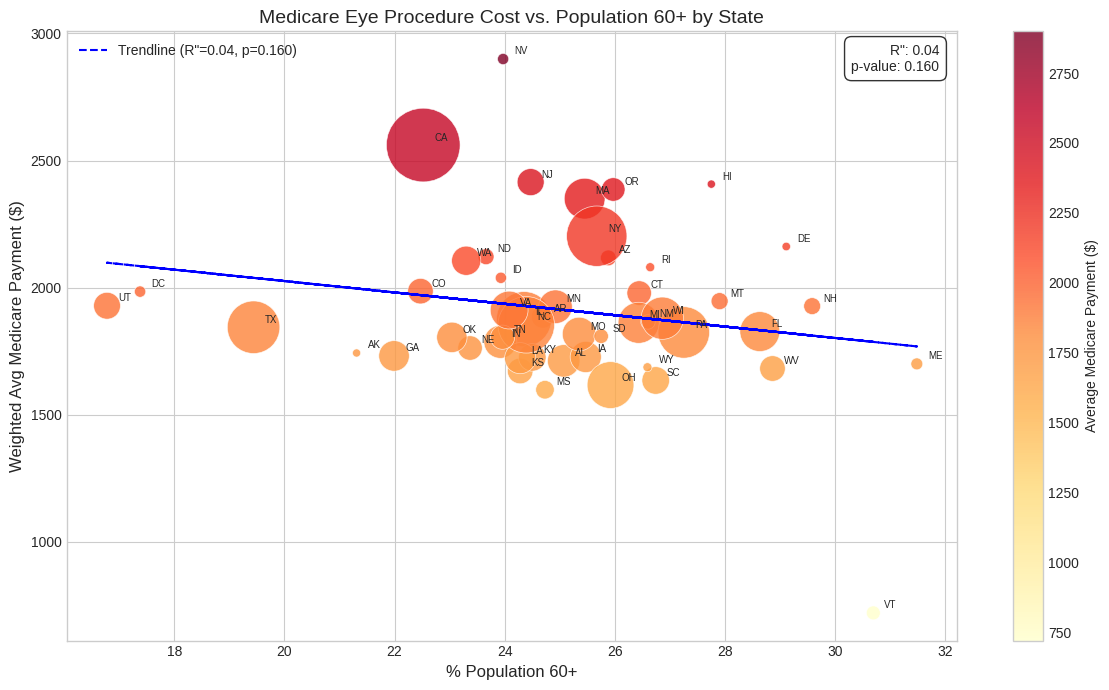


Generating Visualization 3: Correlation Heatmap...


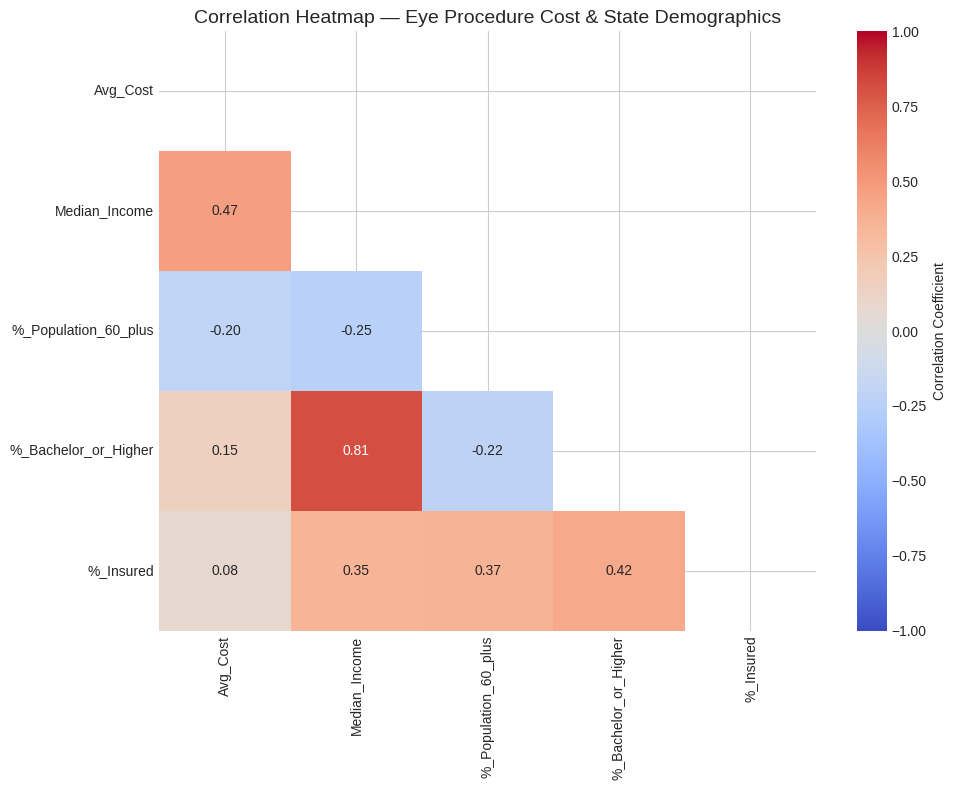


Generating Visualization 4: Bar Chart of Weighted Average Cost by State...


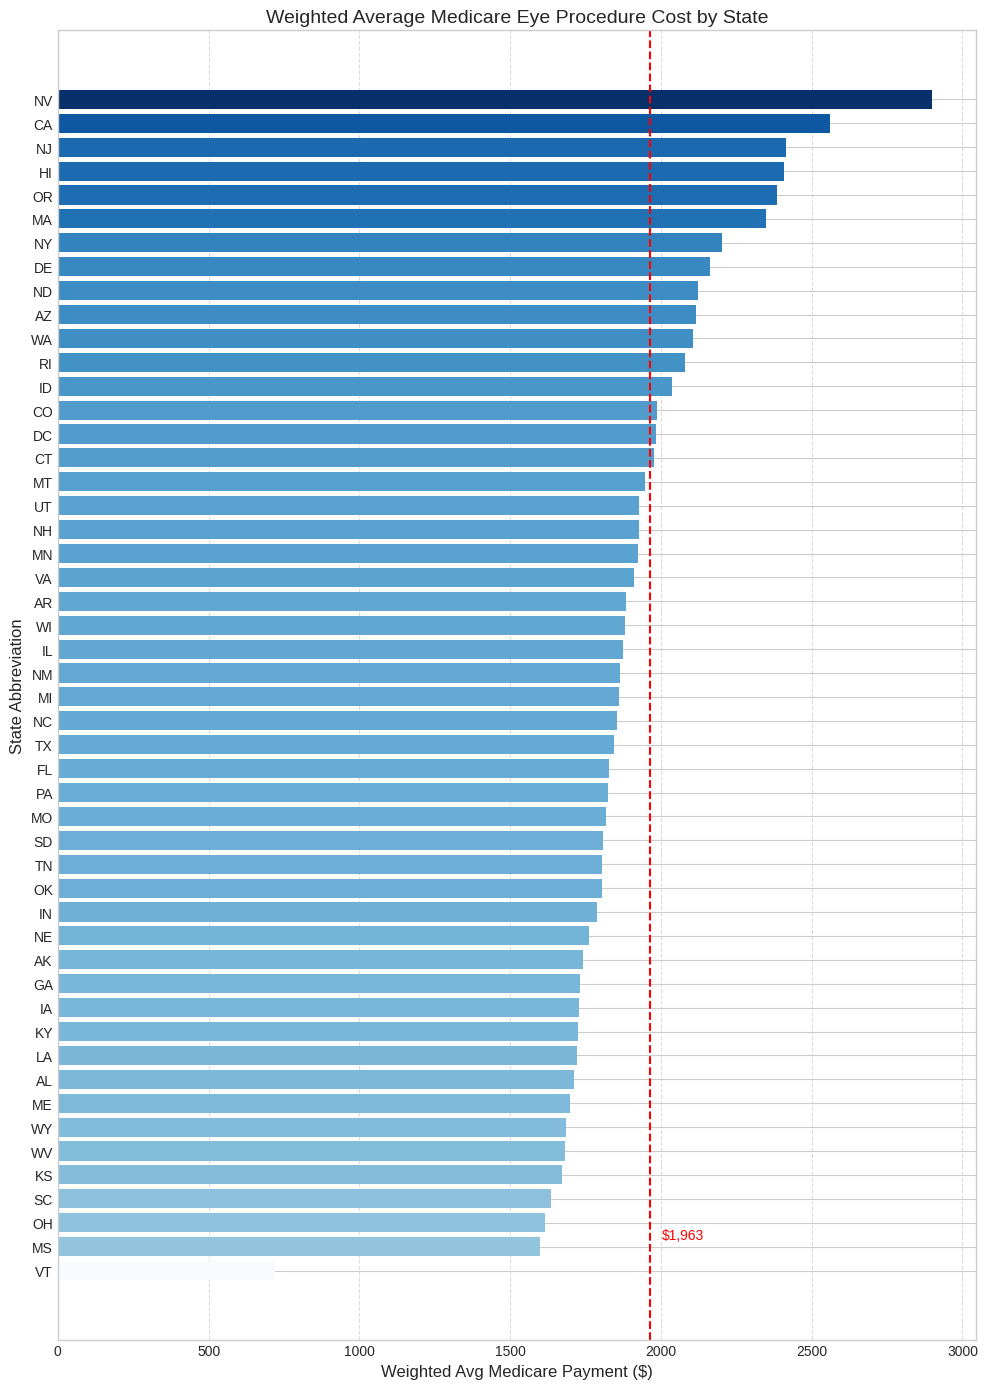

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
from scipy.stats import linregress

# Before plotting, compute a state-level summary used by all 4 visualizations:
state_df = df_final.groupby('Rndrng_Prvdr_State_Abrvtn').apply(
    lambda x: pd.Series({
        'Avg_Cost': np.average(x['Avg_Mdcr_Pymt_Amt'], weights=x['Bene_Cnt']),
        'Median_Income': x['Median_Income'].iloc[0],
        '%_Population_60_plus': x['%_Population_60_plus'].iloc[0],
        '%_Bachelor_or_Higher': x['%_Bachelor_or_Higher'].iloc[0],
        '%_Insured': x['%_Insured'].iloc[0],
        'Total_Benes': x['Bene_Cnt'].sum()
    })
).reset_index()

# Visualization 1 — Plotly Interactive Scatter: Cost vs. Median Income
print("Generating Visualization 1: Plotly Interactive Scatter Plot...")
fig1 = px.scatter(
    state_df,
    x='Median_Income',
    y='Avg_Cost',
    size='Total_Benes',
    color='Avg_Cost',
    color_continuous_scale='RdYlBu_r',
    hover_name='Rndrng_Prvdr_State_Abrvtn',
    hover_data={
        'Rndrng_Prvdr_State_Abrvtn': True,
        'Avg_Cost': '$,.0f',
        'Median_Income': '$,.0f',
        'Total_Benes': ':,.0f'
    },
    trendline='ols',
    text='Rndrng_Prvdr_State_Abrvtn',
    title="Medicare Eye Procedure Cost vs. Median Household Income by State"
)
fig1.update_traces(textposition='top center')
fig1.update_layout(xaxis_title="Median Household Income", yaxis_title="Average Medicare Payment ($)")
fig1.show()

# Visualization 2 — Scatter Plot: Weighted Cost vs. % Population 60+

print("\nGenerating Visualization 2: Matplotlib/Seaborn Scatter Plot...")
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    state_df['%_Population_60_plus'],
    state_df['Avg_Cost'],
    s=state_df['Total_Benes'] / 10, # Scale size
    c=state_df['Avg_Cost'],
    cmap='YlOrRd',
    alpha=0.8,
    edgecolors='w',
    linewidth=0.5
)

# Annotate each dot with state abbreviation
for i, row in state_df.iterrows():
    plt.annotate(
        row['Rndrng_Prvdr_State_Abrvtn'],
        (row['%_Population_60_plus'] + 0.2, row['Avg_Cost'] + 10), # Slight offset
        fontsize=7,
        ha='left',
        va='bottom'
    )

# Add linear regression trend line and display R" and p-value
slope, intercept, r_value, p_value, std_err = linregress(
    state_df['%_Population_60_plus'], state_df['Avg_Cost']
)
line = slope * state_df['%_Population_60_plus'] + intercept
plt.plot(
    state_df['%_Population_60_plus'],
    line,
    color='blue',
    linestyle='--', # Changed to solid line for better visibility
    label=f'Trendline (R"={r_value**2:.2f}, p={p_value:.3f})'
)

# Display R" and p-value in the upper corner
r_squared = r_value**2
plt.text(
    0.98, 0.98,
    f'R": {r_squared:.2f}\np-value: {p_value:.3f}',
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8)
)

plt.xlabel('% Population 60+', fontsize=12)
plt.ylabel('Weighted Avg Medicare Payment ($)', fontsize=12)
plt.title('Medicare Eye Procedure Cost vs. Population 60+ by State', fontsize=14)
plt.colorbar(scatter, label='Average Medicare Payment ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('viz2_cost_age.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualization 3 — Correlation Heatmap
print("\nGenerating Visualization 3: Correlation Heatmap...")
plt.figure(figsize=(10, 8))
correlation_vars = [
    'Avg_Cost',
    'Median_Income',
    '%_Population_60_plus',
    '%_Bachelor_or_Higher',
    '%_Insured'
]
corr_matrix = state_df[correlation_vars].corr()

# Mask the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=mask,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Heatmap — Eye Procedure Cost & State Demographics', fontsize=14)
plt.tight_layout()
plt.savefig('viz3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualization 4 — Bar Chart: Weighted Average Cost by State
print("\nGenerating Visualization 4: Bar Chart of Weighted Average Cost by State...")
state_df_sorted = state_df.sort_values('Avg_Cost', ascending=False)

plt.figure(figsize=(10, 14))

# Create a colormap based on Avg_Cost
norm = plt.Normalize(state_df_sorted['Avg_Cost'].min(), state_df_sorted['Avg_Cost'].max())
cmap = plt.cm.Blues
colors = cmap(norm(state_df_sorted['Avg_Cost']))

plt.barh(
    state_df_sorted['Rndrng_Prvdr_State_Abrvtn'],
    state_df_sorted['Avg_Cost'],
    color=colors
)

# Calculate national weighted average cost from original df_final
national_avg_cost = np.average(df_final['Avg_Mdcr_Pymt_Amt'], weights=df_final['Bene_Cnt'])

# Add vertical dashed line at national weighted average cost
plt.axvline(
    national_avg_cost,
    color='red',
    linestyle='--', # Changed to solid line for better visibility
    linewidth=1.5,
    label=f'National Avg: ${national_avg_cost:,.0f}'
)

# Annotate the national average line with its dollar value
plt.text(
    national_avg_cost * 1.02, # Slightly to the right of the line
    len(state_df_sorted) * 0.95, # Adjust y-position
    f'${national_avg_cost:,.0f}',
    color='red',
    va='center',
    ha='left',
    fontsize=10
)


plt.xlabel('Weighted Avg Medicare Payment ($)', fontsize=12)
plt.ylabel('State Abbreviation', fontsize=12)
plt.title('Weighted Average Medicare Eye Procedure Cost by State', fontsize=14)
plt.gca().invert_yaxis() # Display highest cost at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('viz4_cost_by_state.png', dpi=150, bbox_inches='tight')
plt.show()